# Make sure everything has consistend masks

In [80]:
import numpy as np
import matplotlib.pyplot as plt

data_for_mask = np.load('MetabMaps/Lesion_Double_GT/water_amp_Lesion_Double_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_mask)              # ignoriert NaNs
threshold = 0.01 * mx
brain_mask = (data_for_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
brain_mask[np.isnan(data_for_mask)] = 0
brain_mask = np.swapaxes(brain_mask, -1,0)
brain_mask = np.flip(brain_mask, 1)

import nibabel as nib
import numpy as np

nii = nib.load("Segmentations/GM_lr.nii")      # oder .nii.gz
data = nii.get_fdata()          # -> numpy array (float64)
data_swapped = data*brain_mask
mask = (data_swapped > 1e-3) & np.isfinite(data_swapped)


# Define helper Function for RMSE over time

In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.flip(np.swapaxes(np.load(path), 0, -2), axis=1)/1000000*mask[...,np.newaxis]

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

def error_mean_var_maps(maps, gt, *, mean_over_time=False, ddof=0):
    """
    Compute voxel-wise error mean/variance against GT for 4D metab maps (X,Y,Z,T).

    Parameters
    ----------
    maps : list[np.ndarray] or np.ndarray
        List of recon maps, each shape (X,Y,Z,T), or array shape (N,X,Y,Z,T).
    gt : np.ndarray
        Ground-truth map, shape (X,Y,Z,T).
    mean_over_time : bool
        If True: also average over time => outputs shape (X,Y,Z).
        If False: keep time dimension => outputs shape (X,Y,Z,T).
    ddof : int
        Degrees of freedom for variance (0 = population var, 1 = sample var).

    Returns
    -------
    err_mean : np.ndarray
    err_var  : np.ndarray
    """
    arr = np.stack(maps, axis=0) if isinstance(maps, (list, tuple)) else np.asarray(maps)
    if arr.ndim != 5:
        raise ValueError(f"`maps` must be list of 4D or 5D array, got shape {arr.shape}")
    gt = np.asarray(gt)
    if gt.shape != arr.shape[1:]:
        raise ValueError(f"GT shape {gt.shape} must match maps shape {arr.shape[1:]}")

    err = arr - gt[None, ...]                 # (N,X,Y,Z,T)
    if mean_over_time:
        err = err.mean(axis=-1)               # (N,X,Y,Z)

    err_mean = err.mean(axis=0)               # (X,Y,Z, T) or (X,Y,Z)
    err_var  = err.var(axis=0, ddof=ddof)     # (X,Y,Z, T) or (X,Y,Z)
    return err_mean, err_var

def error_mean_var_for_methods(root, methods, metabolite, gt_method, suffix="Orig", *, mean_over_time=False, ddof=0):
    """
    Convenience wrapper using your loaders.

    Returns
    -------
    err_mean_map, err_var_map : np.ndarray
    """
    gt = load_metab_map(root, gt_method, metabolite, suffix=suffix)
    maps = load_multiple_metab_maps(root, methods, metabolite, suffix=suffix)
    return error_mean_var_maps(maps, gt, mean_over_time=mean_over_time, ddof=ddof)





In [82]:
Noisy_Reps  = ["Lesion_double_noisy_1", "Lesion_double_noisy_2", "Lesion_double_noisy_3", "Lesion_double_noisy_4", "Lesion_double_noisy_5", "Lesion_double_noisy_6"]
Deep_Reps   = ["Lesion_double_deep_tmppca_1", "Lesion_double_deep_tmppca_2", "Lesion_double_deep_tmppca_3", "Lesion_double_deep_tmppca_4", "Lesion_double_deep_tmppca_5", "Lesion_double_deep_tmppca_6"]
tMPPCA_Reps = ["Lesion_double_tmppca_1", "Lesion_double_tmppca_2", "Lesion_double_tmppca_3", "Lesion_double_tmppca_4", "Lesion_double_tmppca_5", "Lesion_double_tmppca_6"]


import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

def plot_error_slice_side_by_side(
    err_left, err_right,
    *,
    t_idx: int,
    z_idx: int,
    title_left="Noisy",
    title_right="Proposed",
    cmap="RdBu_r",
    vlim=None,
):
    """
    err_* shape: (X,Y,Z,T)
    """
    # slice
    A = err_left[z_idx, :, :, t_idx]
    B = err_right[z_idx, :, :, t_idx]

    # symmetric color limits if not given
    if vlim is None:
        vmax = np.nanmax(np.abs([A, B]))
        vlim = (-vmax, vmax)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

    im0 = axes[0].imshow(A.T, origin="lower", cmap=cmap, vmin=vlim[0], vmax=vlim[1])
    im1 = axes[1].imshow(B.T, origin="lower", cmap=cmap, vmin=vlim[0], vmax=vlim[1])

    axes[0].set_title(title_left)
    axes[1].set_title(title_right)

    for ax in axes:
        ax.axis("off")

    # shared colorbar
    cbar = fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label("Error (a.u.)")

    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_gt_maps_and_error_2x4(
    map_gt, map_noisy, map_tmppca, map_deep,
    err_noisy, err_tmppca, err_deep,
    *,
    t_idx: int,
    z_idx: int,
    titles=("GT", "No denoising", "tMPPCA", "Proposed"),
    cmap_map="magma", # hot plasma magma
    cmap_err="RdBu_r",
    vlim_map=None,                 # if None -> (0, max(GT at this timepoint over all z))
    show_gt_error_blank=True,
    map_cbar_label="Amplitude (a.u.)",
    err_cbar_label="Error (a.u.)",
    vlim_err=None,                 # if None -> ± max(|GT| at this timepoint over all z)
):
    """
    Top row:  GT | Noisy | tMPPCA | Proposed   (amplitude maps)
    Bottom:    — | Err(N) | Err(t) | Err(D)    (error maps)

    - Amplitude scale defaults to 0..max(GT) for the CURRENT timepoint t_idx (over all z).
    - Error scale defaults to ±max(|GT|) for the CURRENT timepoint t_idx (over all z).
    Shapes: (X,Y,Z,T). NaNs are ignored for scaling.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # --- extract slices (X,Y) ---
    GT = map_gt[:, :, z_idx, t_idx]
    N  = map_noisy[:, :, z_idx, t_idx]
    Tm = map_tmppca[:, :, z_idx, t_idx]
    D  = map_deep[:, :, z_idx, t_idx]

    EN  = err_noisy[:, :, z_idx, t_idx]
    ETm = err_tmppca[:, :, z_idx, t_idx]
    ED  = err_deep[:, :, z_idx, t_idx]

    # --- amplitude color limits (FIXED to GT, current timepoint only) ---
    if vlim_map is None:
        gt_t = map_gt[:, :, :, t_idx]  # all z, current t
        gt_vals = np.abs(gt_t[np.isfinite(gt_t)])

        gt_min = np.percentile(gt_vals, 2)#461741 #np.percentile(gt_vals, 2)
        gt_max = np.percentile(gt_vals, 99.5)#1656237# np.percentile(gt_vals, 98)

        vlim_map = (gt_min, gt_max)

        norm_amp = colors.PowerNorm(
            gamma=1,
            vmin=gt_min,
            vmax=gt_max
        )

    # --- error color limits (FIXED to ± max(|GT|), current timepoint only) ---
    if vlim_err is None:
        gt_t = map_gt[:, :, :, t_idx]  # all z, current t
        gt_abs = np.abs(gt_t[np.isfinite(gt_t)])
        v = 0.8*gt_max#np.percentile(gt_vals, 98)#np.percentile(gt_abs, 99)  # Glx: 93, Lac: 
        vlim_err = (-v, v)

    # --- figure layout ---
    fig, axes = plt.subplots(2, 4, figsize=(12.0, 6.0))
    plt.subplots_adjust(right=0.88, wspace=0.02, hspace=0.08)

    # ----- TOP: amplitude maps -----
    top_arrays = [GT, N, Tm, D]
    ims_top = []
    for j, (A, title) in enumerate(zip(top_arrays, titles)):
        im = axes[0, j].imshow(
            A.T, origin="lower",
            cmap=cmap_map,
            norm=norm_amp,
        )
        axes[0, j].set_title(title)
        ims_top.append(im)
    
    # ----- BOTTOM: error maps -----
    if show_gt_error_blank:
        axes[1, 0].imshow(
            np.zeros_like(GT).T,
            origin="lower",
            cmap=cmap_err,
            vmin=vlim_err[0], vmax=vlim_err[1],
            alpha=0.0,
        )
        axes[1, 0].text(
            0.5, 0.5, "—",
            ha="center", va="center",
            transform=axes[1, 0].transAxes,
            fontsize=16,
        )
    else:
        axes[1, 0].imshow(
            np.zeros_like(GT).T,
            origin="lower",
            cmap=cmap_err,
            vmin=vlim_err[0], vmax=vlim_err[1],
        )

    im_err_N  = axes[1, 1].imshow(EN.T,  origin="lower", cmap=cmap_err,
                                  vmin=vlim_err[0], vmax=vlim_err[1])
    im_err_Tm = axes[1, 2].imshow(ETm.T, origin="lower", cmap=cmap_err,
                                  vmin=vlim_err[0], vmax=vlim_err[1])
    im_err_D  = axes[1, 3].imshow(ED.T,  origin="lower", cmap=cmap_err,
                                  vmin=vlim_err[0], vmax=vlim_err[1])

    # --- remove axes decorations ---
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)

    # --- colorbars on dedicated axes (right side) ---
    cax_map = fig.add_axes([0.90, 0.56, 0.02, 0.30])
    cax_err = fig.add_axes([0.90, 0.13, 0.02, 0.30])

    cb_map = fig.colorbar(ims_top[-1], cax=cax_map)
    cb_map.set_label(map_cbar_label)

    cb_err = fig.colorbar(im_err_D, cax=cax_err)
    cb_err.set_label(err_cbar_label)

    plt.show()




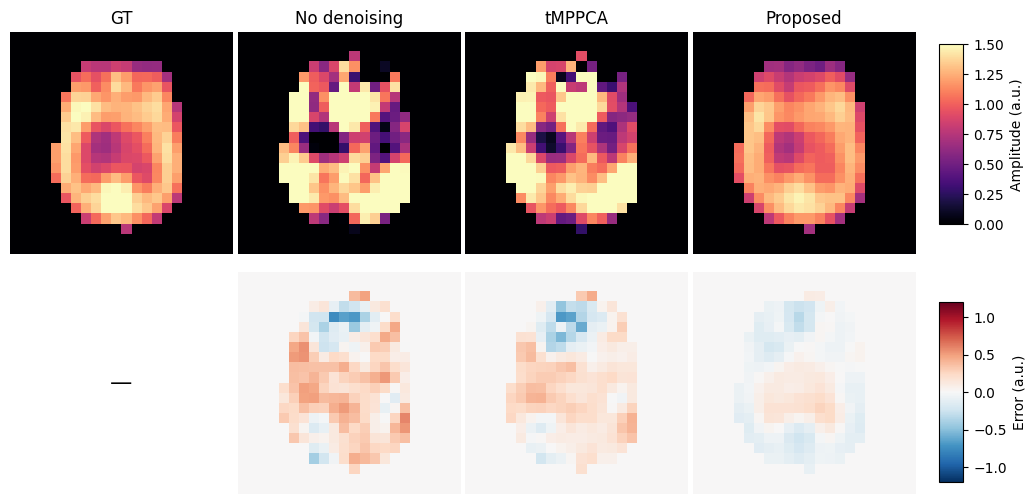

In [83]:
t_idx = 3    # first repetition
z_idx = 11       # choose slice
Metabo = "Glx"

# plot_error_slice_side_by_side(
#     err_mean_tMPPCA,    #err_mean_tMPPCA
#     err_mean_deep,
#     t_idx=t_idx,
#     z_idx=z_idx,
#     title_left="No denoising",
#     title_right="Proposed",
# )


gt_map    = load_metab_map("MetabMaps", "Lesion_Double_GT", Metabo, suffix="Orig")
noisy_map = load_metab_map("MetabMaps", Noisy_Reps[0],       Metabo, suffix="Orig")
tmppca_map= load_metab_map("MetabMaps", tMPPCA_Reps[0],      Metabo, suffix="Orig")
deep_map  = load_metab_map("MetabMaps", Deep_Reps[0],        Metabo, suffix="Orig")

err_mean_noisy, err_var_noisy = error_mean_var_for_methods(
    root="MetabMaps",
    methods=Noisy_Reps,
    metabolite=Metabo,
    gt_method="Lesion_Double_GT",
    suffix="Orig",
    mean_over_time=False,   # keep (X,Y,Z,T)
)

err_mean_deep, err_var_deep = error_mean_var_for_methods(
    root="MetabMaps",
    methods=Deep_Reps,
    metabolite=Metabo,
    gt_method="Lesion_Double_GT",
    suffix="Orig",
    mean_over_time=False,   # keep (X,Y,Z,T)
)

err_mean_tMPPCA, err_var_tMPPCA = error_mean_var_for_methods(
    root="MetabMaps",
    methods=tMPPCA_Reps,
    metabolite=Metabo,
    gt_method="Lesion_Double_GT",
    suffix="Orig",
    mean_over_time=False,   # keep (X,Y,Z,T)
)

plot_gt_maps_and_error_2x4(
    gt_map, noisy_map, tmppca_map, deep_map,
    err_mean_noisy, err_mean_tMPPCA, err_mean_deep,
    t_idx=t_idx, z_idx=z_idx,
    titles=("GT", "No denoising", "tMPPCA", "Proposed"),
)




In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

def plot_sim_maps_with_per_column_cbars(
    maps,
    errs,
    *,
    t_idx: int,
    z_idx: int,
    methods=("GT", "Proposed", "tMPPCA", "No denoising"),
    metabolites=("Glx", "Lac"),
    cmap_map="magma",
    cmap_err="RdBu_r",
    title=None,
    amp_cbar_labels=("Glx [a.u.]", "Lac [a.u.]"),
    err_cbar_labels=("Glx error [a.u.]", "Lac error [a.u.]"),
    err_scale_factor=0.8,
    # layout controls
    figsize=None,
    gap=0.06,          # width of gap column
    wspace=0.06,
    hspace=0.02,
    cbar_height=0.035, # height in figure coordinates
    cbar_pad=0.008,    # vertical pad between bottom plots and cbars
):
    def slc4(A):
        return A[:, :, z_idx, t_idx]

    # ----- compute per-metabolite amplitude limits from GT (over all z at t_idx) -----
    amp_norm = {}
    gt_max_per_metab = {}
    for m in metabolites:
        gt_t = maps["GT"][m][:, :, :, t_idx]
        gt_vals = gt_t[np.isfinite(gt_t)]
        if gt_vals.size == 0:
            gt_min, gt_max = 0.0, 1.0
        else:
            gt_min = np.percentile(gt_vals, 2)
            gt_max = np.percentile(gt_vals, 99.5)
            if gt_max <= gt_min:
                gt_max = gt_min + 1e-6
        amp_norm[m] = colors.Normalize(vmin=gt_min, vmax=gt_max)
        gt_max_per_metab[m] = gt_max

    # ----- error limits per metabolite -----
    err_lim = {m: (-err_scale_factor * gt_max_per_metab[m],
                   +err_scale_factor * gt_max_per_metab[m]) for m in metabolites}

    nrows = len(methods)
    if figsize is None:
        figsize = (8.8, 1.6*nrows + 0.9)

    fig = plt.figure(figsize=figsize)

    # Grid for images only (no cbar row!)
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=5,
        width_ratios=[1, 1, gap, 1, 1],
        wspace=wspace,
        hspace=hspace
    )

    col_titles = [metabolites[0], metabolites[1], "", f"{metabolites[0]} error", f"{metabolites[1]} error"]

    # store axes of the bottom row for each column we want a colorbar under
    bottom_axes = {}  # keys: ("amp", metab) or ("err", metab)
    mappable_amp = {metabolites[0]: None, metabolites[1]: None}
    mappable_err = {metabolites[0]: None, metabolites[1]: None}

    for r, meth in enumerate(methods):
        # --- amplitude cols 0,1 ---
        for c, m in enumerate(metabolites):
            ax = fig.add_subplot(gs[r, c])
            A = slc4(maps[meth][m])
            im = ax.imshow(A.T, origin="lower", cmap=cmap_map, norm=amp_norm[m])
            if mappable_amp[m] is None:
                mappable_amp[m] = im

            if r == 0:
                ax.set_title(col_titles[c], pad=6)
            if c == 0:
                ax.set_ylabel(meth, rotation=90, fontsize=11, labelpad=12)

            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)

            if r == nrows - 1:
                bottom_axes[("amp", m)] = ax

        # gap col 2
        ax_gap = fig.add_subplot(gs[r, 2])
        ax_gap.axis("off")

        # --- error cols 3,4 ---
        for c, m in enumerate(metabolites):
            ax = fig.add_subplot(gs[r, c+3])

            if r == 0:
                ax.set_title(col_titles[c+3], pad=6)

            if meth == "GT" or errs.get(meth, {}).get(m, None) is None:
                ax.text(0.5, 0.5, "", ha="center", va="center", transform=ax.transAxes, fontsize=16)
            else:
                E = slc4(errs[meth][m])
                imE = ax.imshow(E.T, origin="lower", cmap=cmap_err,
                                vmin=err_lim[m][0], vmax=err_lim[m][1])
                if mappable_err[m] is None:
                    mappable_err[m] = imE

            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)

            if r == nrows - 1:
                bottom_axes[("err", m)] = ax

    if title is not None:
        fig.text(0.02, 0.98, title, ha="left", va="top", fontsize=13)

    # ----- Create colorbars with EXACT same width as the corresponding bottom axes -----
    def add_cbar_under(ax_ref, mappable, label):
        bbox = ax_ref.get_position()  # in figure coordinates
        cax = fig.add_axes([bbox.x0, bbox.y0 - cbar_pad - cbar_height, bbox.width, cbar_height])
        cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
        cb.set_label(label, fontsize=9)
        cb.ax.tick_params(labelsize=8)
        return cb

    add_cbar_under(bottom_axes[("amp", metabolites[0])], mappable_amp[metabolites[0]], amp_cbar_labels[0])
    add_cbar_under(bottom_axes[("amp", metabolites[1])], mappable_amp[metabolites[1]], amp_cbar_labels[1])
    add_cbar_under(bottom_axes[("err", metabolites[0])], mappable_err[metabolites[0]], err_cbar_labels[0])
    add_cbar_under(bottom_axes[("err", metabolites[1])], mappable_err[metabolites[1]], err_cbar_labels[1])

    # leave room at bottom for cbars
    fig.subplots_adjust(bottom=0.12)

    plt.savefig("simulationMaps.pdf", bbox_inches="tight")
    plt.show()





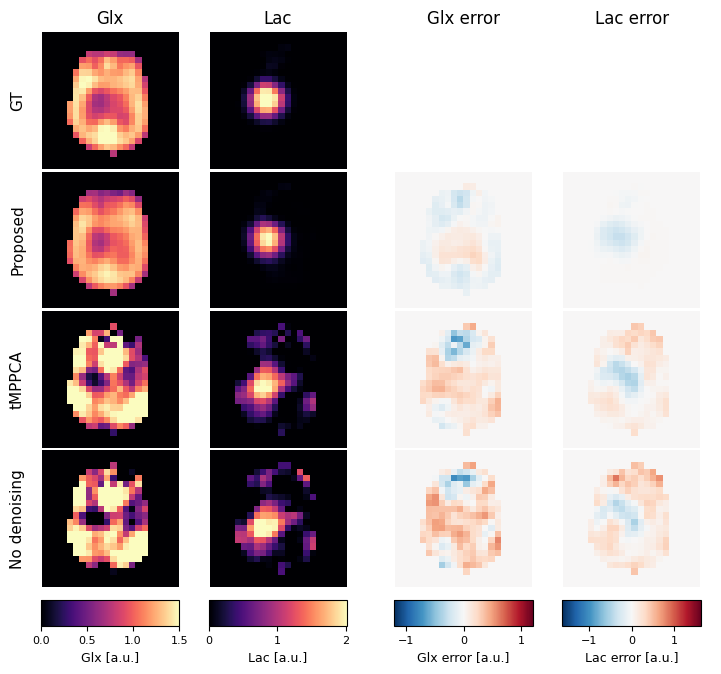

In [85]:
methods = ["GT", "Proposed", "tMPPCA", "No denoising"]

maps = {
  "GT": {
    "Glx": load_metab_map("MetabMaps", "Lesion_Double_GT", "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", "Lesion_Double_GT", "Lac", suffix="Orig"),
  },
  "No denoising": {
    "Glx": load_metab_map("MetabMaps", Noisy_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", Noisy_Reps[0], "Lac", suffix="Orig"),
  },
  "tMPPCA": {
    "Glx": load_metab_map("MetabMaps", tMPPCA_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", tMPPCA_Reps[0], "Lac", suffix="Orig"),
  },
  "Proposed": {
    "Glx": load_metab_map("MetabMaps", Deep_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", Deep_Reps[0], "Lac", suffix="Orig"),
  },
}

# errors: mean across reps for each method
err_noisy_glx, _  = error_mean_var_for_methods("MetabMaps", Noisy_Reps,  "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_tmppca_glx, _ = error_mean_var_for_methods("MetabMaps", tMPPCA_Reps, "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_deep_glx, _   = error_mean_var_for_methods("MetabMaps", Deep_Reps,   "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)

err_noisy_lac, _  = error_mean_var_for_methods("MetabMaps", Noisy_Reps,  "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_tmppca_lac, _ = error_mean_var_for_methods("MetabMaps", tMPPCA_Reps, "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_deep_lac, _   = error_mean_var_for_methods("MetabMaps", Deep_Reps,   "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)

errs = {
  "GT": {"Glx": None, "Lac": None},  # unused
  "No denoising": {"Glx": err_noisy_glx, "Lac": err_noisy_lac},
  "tMPPCA": {"Glx": err_tmppca_glx, "Lac": err_tmppca_lac},
  "Proposed": {"Glx": err_deep_glx, "Lac": err_deep_lac},
}



plot_sim_maps_with_per_column_cbars(
    maps, errs,
    t_idx=t_idx, z_idx=z_idx,
    methods=("GT", "Proposed", "tMPPCA", "No denoising"),
    metabolites=("Glx", "Lac"),
    title = None
)



In [86]:
def plot_segmentation_row(
    segs,
    *,
    z_idx: int,
    order=("GM", "WM", "CSF", "Lesion"),
    row_label="Segmentations",
    title=None,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    figsize=(8.8, 1.6),
    wspace=0.02,
    hspace=0.02,
):
    import numpy as np
    import matplotlib.pyplot as plt

    def slc3(A):
        A = np.squeeze(A)
        if A.ndim != 3:
            raise ValueError(f"Expected segmentation with 3 dims after squeeze, got shape {A.shape}")
        return A[:, :, z_idx]

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[1, 1, 1, 1],
        wspace=wspace,
        hspace=hspace
    )

    axes = []
    for c, name in enumerate(order):
        ax = fig.add_subplot(gs[0, c])
        axes.append(ax)

        A = slc3(segs[name])
        ax.set_facecolor("black")
        ax.imshow(A.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)

        ax.set_title(name, pad=6)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)

    # ---- Zeilenlabel links ----
    if row_label is not None:
        # Position relativ zur ersten Achse
        bbox = axes[0].get_position()
        fig.text(
            bbox.x0 - 0.02,               # Abstand links
            bbox.y0 + bbox.height / 2,
            row_label,
            rotation=90,
            va="center",
            ha="center",
            fontsize=11
        )

    if title is not None:
        fig.text(0.02, 0.98, title, ha="left", va="top", fontsize=13)

    plt.savefig("segmentationsRow.pdf", bbox_inches="tight")
    plt.show()



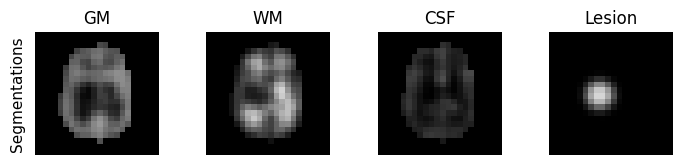

In [87]:
import nibabel as nib
import numpy as np

mask2 = mask  # (X,Y,Z) 0/1

GM  = nib.load("Segmentations/GM_lr.nii").get_fdata().astype(np.float32) * mask2
WM  = nib.load("Segmentations/WM_lr.nii").get_fdata().astype(np.float32) * mask2
CSF = nib.load("Segmentations/CSF_lr.nii").get_fdata().astype(np.float32) * mask2
LES = nib.load("Segmentations/Lesion_lr.nii").get_fdata().astype(np.float32) * mask2

segs = {"GM": GM, "WM": WM, "CSF": CSF, "Lesion": LES}

plot_segmentation_row(segs, z_idx=11, title=None)



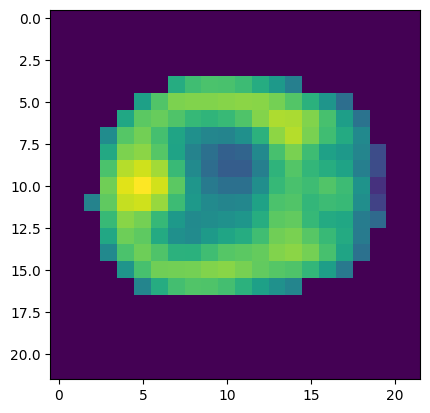

In [88]:
MAP = np.flip(np.swapaxes(np.load("MetabMaps/Lesion_Double_GT/Glx_amp_Lesion_Double_GT_Orig.npy"), 0, -2), axis=1)

plt.imshow(MAP[...,z,-1])